In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
from utils.constants import *

# Load English datasets
en_data = {}
en_data['2020'] = pd.read_csv(os.path.join(ASSET_DIR, CSV_EN_2020))
en_data['2025'] = pd.read_csv(os.path.join(ASSET_DIR, CSV_EN_2025))

# Load German datasets
de_data = {}
de_data['2020'] = pd.read_csv(os.path.join(ASSET_DIR, CSV_DE_2020))
de_data['2025'] = pd.read_csv(os.path.join(ASSET_DIR, CSV_DE_2025))

print(f"English data loaded:")
for year, df in en_data.items():
    print(f"  {year}: shape {df.shape}")

print(f"German data loaded:")
for year, df in de_data.items():
    print(f"  {year}: shape {df.shape}")


English data loaded:
  2020: shape (103192, 11)
  2025: shape (72726, 11)
German data loaded:
  2020: shape (4654, 11)
  2025: shape (22669, 11)


In [12]:
import json
import re
from pathlib import Path

def load_keywords(path):
    with Path(path).open('r', encoding='utf-8') as f:
        raw_keywords = json.load(f)

    return [
        keyword
        for keywords in raw_keywords.values()
        for keyword in keywords
        if isinstance(keyword, str) and keyword.strip()
    ]

en_keywords = load_keywords(os.path.join(KEYWORD_DIR, JSON_DISTRESS_EN))
de_keywords = load_keywords(os.path.join(KEYWORD_DIR, JSON_DISTRESS_DE))

print(f"Loaded {len(en_keywords)} English distress keywords")
print(f"Loaded {len(de_keywords)} German distress keywords")

def count_keyword_hits(text: str, keywords) -> int:
    text = str(text).lower()
    return sum(len(re.findall(re.escape(keyword.lower()), text)) for keyword in keywords)

def get_token_count(text: str) -> int:
    return len(re.findall(r'\b\w+\b', str(text).lower()))

def score_text(text: str, keywords) -> float:
    hits = count_keyword_hits(text, keywords)
    token_count = get_token_count(text)
    return hits / token_count if token_count > 0 else 0.0

for lang_name, data_dict, keywords in [
    ('English', en_data, en_keywords),
    ('German', de_data, de_keywords),
]:
    for year, df in data_dict.items():
        texts = df['text_for_keywords'].fillna('').astype(str)
        df['distress_hit_count'] = texts.map(lambda text: count_keyword_hits(text, keywords))
        df['distress_score'] = texts.map(lambda text: score_text(text, keywords))
        data_dict[year] = df
        avg_score = df['distress_score'].mean()
        print(f'{lang_name} {year}: rows={len(df)}, avg_score={avg_score:.4f}')


Loaded 376 English distress keywords
Loaded 128 German distress keywords
English 2020: rows=103192, avg_score=0.0066
English 2025: rows=72726, avg_score=0.0065
German 2020: rows=4654, avg_score=0.0000
German 2025: rows=22669, avg_score=0.0000


In [13]:
# Descriptive Statistics (2020 vs 2025 comparison)
from scipy import stats
import seaborn as sns

comparison_rows = []
for lang_name, data_dict in [('English', en_data), ('German', de_data)]:
    for year, df in data_dict.items():
        scores = df['distress_score'].dropna()
        comparison_rows.append({
            'Language': lang_name,
            'Year': year,
            'N': len(scores),
            'Mean': scores.mean(),
            'Median': scores.median(),
            'Std': scores.std(),
            'Min': scores.min(),
            'Max': scores.max(),
            'Q1': scores.quantile(0.25),
            'Q3': scores.quantile(0.75),
        })

comparison_df = pd.DataFrame(comparison_rows)
print("\nDetailed Statistics:")
print(comparison_df.to_string(index=False))

# Calculate year-over-year change
print("\n" + "=" * 70)
print("Year-over-Year Changes:")
print("=" * 70)
for lang_name in ['English', 'German']:
    lang_data = comparison_df[comparison_df['Language'] == lang_name]
    if len(lang_data) == 2:
        data_2020 = lang_data[lang_data['Year'] == '2020'].iloc[0]
        data_2025 = lang_data[lang_data['Year'] == '2025'].iloc[0]
        
        mean_change = data_2025['Mean'] - data_2020['Mean']
        mean_pct_change = (mean_change / data_2020['Mean'] * 100) if data_2020['Mean'] != 0 else float('inf')
        
        print(f"\n{lang_name}:")
        print(f"  Mean:   {data_2020['Mean']:.6f} → {data_2025['Mean']:.6f} (Δ = {mean_change:+.6f}, {mean_pct_change:+.1f}%)")
        print(f"  Median: {data_2020['Median']:.6f} → {data_2025['Median']:.6f}")
        print(f"  Std:    {data_2020['Std']:.6f} → {data_2025['Std']:.6f}")

# Save comparison results
comparison_df.to_csv(os.path.join(ASSET_DIR, 'distress_2020_vs_2025_comparison.csv'), index=False)
print(f"\n✓ Saved comparison table to: distress_2020_vs_2025_comparison.csv")



Detailed Statistics:
Language Year      N     Mean   Median      Std  Min      Max  Q1       Q3
 English 2020 103192 0.006569 0.003311 0.009466  0.0 0.153846 0.0 0.010101
 English 2025  72726 0.006496 0.003597 0.009229  0.0 0.166667 0.0 0.010025
  German 2020   4654 0.000000 0.000000 0.000000  0.0 0.000000 0.0 0.000000
  German 2025  22669 0.000000 0.000000 0.000000  0.0 0.000000 0.0 0.000000

Year-over-Year Changes:

English:
  Mean:   0.006569 → 0.006496 (Δ = -0.000073, -1.1%)
  Median: 0.003311 → 0.003597
  Std:    0.009466 → 0.009229

German:
  Mean:   0.000000 → 0.000000 (Δ = +0.000000, +inf%)
  Median: 0.000000 → 0.000000
  Std:    0.000000 → 0.000000

✓ Saved comparison table to: distress_2020_vs_2025_comparison.csv


In [14]:
# Statistical Tests (Mann-Whitney U + Cohen's d)

def cohens_d(group1, group2):
    """Calculate Cohen's d effect size"""
    n1, n2 = len(group1), len(group2)
    var1, var2 = group1.var(), group2.var()
    pooled_std = np.sqrt(((n1 - 1) * var1 + (n2 - 1) * var2) / (n1 + n2 - 2))
    return (group1.mean() - group2.mean()) / pooled_std

def interpret_cohens_d(d):
    """Interpret Cohen's d effect size"""
    abs_d = abs(d)
    if abs_d < 0.2:
        return "negligible"
    elif abs_d < 0.5:
        return "small"
    elif abs_d < 0.8:
        return "medium"
    else:
        return "large"

test_results = []
for lang_name, data_dict in [('English', en_data), ('German', de_data)]:
    scores_2020 = data_dict['2020']['distress_score'].dropna()
    scores_2025 = data_dict['2025']['distress_score'].dropna()
    
    # Mann-Whitney U test (non-parametric)
    u_stat, mw_p_value = stats.mannwhitneyu(scores_2020, scores_2025, alternative='two-sided')
    
    # Cohen's d
    cohens_d_val = cohens_d(scores_2020, scores_2025)
    effect_size_interpretation = interpret_cohens_d(cohens_d_val)
    
    # Rank-biserial correlation (effect size for Mann-Whitney U)
    n1, n2 = len(scores_2020), len(scores_2025)
    rank_biserial = 1 - (2 * u_stat) / (n1 * n2)
    
    test_results.append({
        'Language': lang_name,
        'MannWhitney_U': u_stat,
        'p_value': mw_p_value,
        'Significant': 'Yes' if mw_p_value < 0.05 else 'No',
        'Cohen_d': cohens_d_val,
        'Effect_Size': effect_size_interpretation,
        'Rank_Biserial': rank_biserial,
    })
    
    print(f"\n{lang_name}:")
    print(f"  Mann-Whitney U = {u_stat:.2f}, p-value = {mw_p_value:.4f} {'*' if mw_p_value < 0.05 else '(ns)'}")
    print(f"  Cohen's d = {cohens_d_val:.4f} ({effect_size_interpretation})")
    print(f"  Rank-biserial correlation = {rank_biserial:.4f}")
    if mw_p_value < 0.05:
        print(f"  → SIGNIFICANT difference between 2020 and 2025")
    else:
        print(f"  → NO significant difference between 2020 and 2025")

test_results_df = pd.DataFrame(test_results)
test_results_df.to_csv(os.path.join(ASSET_DIR, 'distress_statistical_tests.csv'), index=False)
print(f"\n✓ Saved test results to: distress_statistical_tests.csv")


English:
  Mann-Whitney U = 3738048367.50, p-value = 0.1493 (ns)
  Cohen's d = 0.0078 (negligible)
  Rank-biserial correlation = 0.0038
  → NO significant difference between 2020 and 2025

German:
  Mann-Whitney U = 52750763.00, p-value = 1.0000 (ns)
  Cohen's d = nan (large)
  Rank-biserial correlation = 0.0000
  → NO significant difference between 2020 and 2025

✓ Saved test results to: distress_statistical_tests.csv


/var/folders/qs/wnkjdcc560xf7634r7rj22zr0000gn/T/ipykernel_14245/2847838020.py:8: RuntimeWarning: invalid value encountered in scalar divide
  return (group1.mean() - group2.mean()) / pooled_std


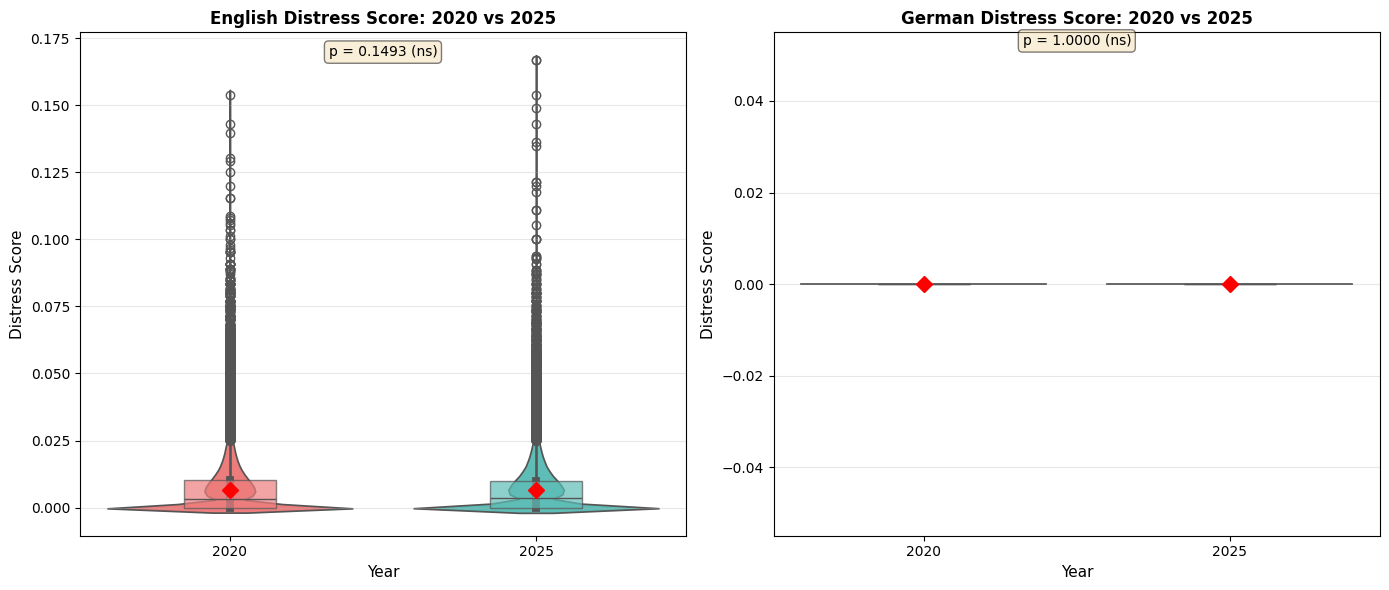

✓ Saved violin plot to: distress_violin_plot_2020_vs_2025.png


In [18]:
# Visualization - Violin Plots

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for idx, (lang_name, data_dict) in enumerate([('English', en_data), ('German', de_data)]):
    ax = axes[idx]
    
    # Prepare data for violin plot
    plot_data = []
    for year in ['2020', '2025']:
        scores = data_dict[year]['distress_score'].dropna()
        for score in scores:
            plot_data.append({'Year': year, 'Distress Score': score})
    
    plot_df = pd.DataFrame(plot_data)
    
    # Create violin plot
    sns.violinplot(data=plot_df, x='Year', y='Distress Score', ax=ax, hue='Year', palette=['#FF6B6B', '#4ECDC4'], legend=False)
    
    # Add box plot overlay for clarity
    sns.boxplot(data=plot_df, x='Year', y='Distress Score', ax=ax, width=0.3, 
                hue='Year', palette=['#FF6B6B', '#4ECDC4'], showcaps=False, boxprops=dict(alpha=0.7), whiskerprops=dict(alpha=0), legend=False)
    
    # Add mean markers
    means = plot_df.groupby('Year')['Distress Score'].mean()
    for i, (year, mean) in enumerate(means.items()):
        ax.plot(i, mean, marker='D', color='red', markersize=8, label='Mean' if i == 0 else '', zorder=3)
    
    ax.set_title(f'{lang_name} Distress Score: 2020 vs 2025', fontsize=12, fontweight='bold')
    ax.set_ylabel('Distress Score', fontsize=11)
    ax.set_xlabel('Year', fontsize=11)
    ax.grid(axis='y', alpha=0.3)
    
    # Add statistical annotation
    lang_test = test_results_df[test_results_df['Language'] == lang_name].iloc[0]
    p_val = lang_test['p_value']
    sig_text = f"p = {p_val:.4f} *" if p_val < 0.05 else f"p = {p_val:.4f} (ns)"
    ax.text(0.5, ax.get_ylim()[1] * 0.95, sig_text, ha='center', fontsize=10, 
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.savefig(os.path.join(ASSET_DIR, 'distress_violin_plot_2020_vs_2025.png'), dpi=300, bbox_inches='tight')
plt.show()
print(f"✓ Saved violin plot to: distress_violin_plot_2020_vs_2025.png")


In [16]:

print("\n" + "=" * 70)
print("SUMMARY")
print("=" * 70)
print("\nKey Findings:")
for _, row in test_results_df.iterrows():
    print(f"\n{row['Language']}:")
    print(f"  - Statistical Significance: {row['Significant']} (p = {row['p_value']:.4f})")
    print(f"  - Effect Size: {row['Effect_Size']} (Cohen's d = {row['Cohen_d']:.4f})")


SUMMARY

Key Findings:

English:
  - Statistical Significance: No (p = 0.1493)
  - Effect Size: negligible (Cohen's d = 0.0078)

German:
  - Statistical Significance: No (p = 1.0000)
  - Effect Size: large (Cohen's d = nan)
